In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_DIR = r"Garbage classification_dataset"  

print("Folders found:", os.listdir(DATA_DIR))

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_data.class_indices)

Folders found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


IMG_SAVE_DIR = "images"
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

num_classes = 6
img_size = 224


model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    Dropout(0.25),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 dropout_1 (Dropout)         (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 112, 112, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 64)     

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#  Create folders
os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 2. Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',  # watch validation accuracy
    patience=3,              # stop if no improvement for 3 epochs
    restore_best_weights=True, # go back to best epoch
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='garbage_model.h5', 
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train with callbacks
epochs = 15 

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

#  Save plots to images folder
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.savefig(os.path.join("images", 'accuracy_plot.png'))

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.savefig(os.path.join("images", 'loss_plot.png'))

plt.show()
print("Training done. Best model saved to: models/best_garbage_model.h5")
print("Plots saved to: images/")

Epoch 1/15
64/64 [==============================] - ETA: 0s - loss: 1.5617 - accuracy: 0.5277
Epoch 1: val_accuracy improved from -inf to 0.15905, saving model to garbage_model.h5


c:\Users\ADMIN\miniconda3\envs\tfml\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


64/64 [==============================] - 433s 7s/step - loss: 1.5617 - accuracy: 0.5277 - val_loss: 73.6866 - val_accuracy: 0.1590
Epoch 2/15
64/64 [==============================] - ETA: 0s - loss: 1.0680 - accuracy: 0.6304
Epoch 2: val_accuracy did not improve from 0.15905
64/64 [==============================] - 406s 6s/step - loss: 1.0680 - accuracy: 0.6304 - val_loss: 30.8594 - val_accuracy: 0.1551
Epoch 3/15
64/64 [==============================] - ETA: 0s - loss: 0.8316 - accuracy: 0.7055
Epoch 3: val_accuracy improved from 0.15905 to 0.21670, saving model to garbage_model.h5
64/64 [==============================] - 399s 6s/step - loss: 0.8316 - accuracy: 0.7055 - val_loss: 6.8581 - val_accuracy: 0.2167
Epoch 4/15
64/64 [==============================] - ETA: 0s - loss: 0.6841 - accuracy: 0.7732
Epoch 4: val_accuracy improved from 0.21670 to 0.24056, saving model to garbage_model.h5
64/64 [==============================] - 369s 6s/step - loss: 0.6841 - accuracy: 0.7732 - val_los

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)

num_classes = 6
img_size = 224

# 1. Load MobileNetV2 pretrained on ImageNet. 
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # freeze base

# 2. Add  own classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 [==============================] - 2s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (N

Epoch 1/15
64/64 [==============================] - ETA: 0s - loss: 1.0575 - accuracy: 0.5954
Epoch 1: val_accuracy improved from -inf to 0.71372, saving model to garbage_model.h5
64/64 [==============================] - 150s 2s/step - loss: 1.0575 - accuracy: 0.5954 - val_loss: 0.7432 - val_accuracy: 0.7137
Epoch 2/15
64/64 [==============================] - ETA: 0s - loss: 0.6421 - accuracy: 0.7658
Epoch 2: val_accuracy improved from 0.71372 to 0.73161, saving model to garbage_model.h5
64/64 [==============================] - 113s 2s/step - loss: 0.6421 - accuracy: 0.7658 - val_loss: 0.6995 - val_accuracy: 0.7316
Epoch 3/15
64/64 [==============================] - ETA: 0s - loss: 0.5195 - accuracy: 0.8182
Epoch 3: val_accuracy improved from 0.73161 to 0.75547, saving model to garbage_model.h5
64/64 [==============================] - 114s 2s/step - loss: 0.5195 - accuracy: 0.8182 - val_loss: 0.6022 - val_accuracy: 0.7555
Epoch 4/15
64/64 [==============================] - ETA: 0s - lo

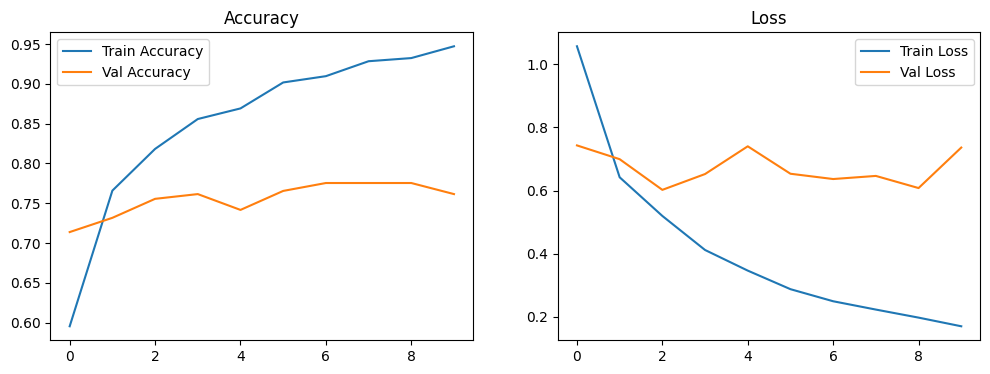

Training done. Best model saved to: models/best_garbage_model.h5
Plots saved to: images/


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#  Create folders
os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 2. Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',  # watch validation accuracy
    patience=3,              # stop if no improvement for 3 epochs
    restore_best_weights=True, # go back to best epoch
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='garbage_model.h5', 
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train with callbacks
epochs = 15 

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

#  Save plots to images folder
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.savefig(os.path.join("images", 'accuracy_plot.png'))

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.savefig(os.path.join("images", 'loss_plot.png'))

plt.show()
print("Training done. Best model saved to: models/best_garbage_model.h5")
print("Plots saved to: images/")